# Model Building

## 1: Imports and Data Loading

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Load the pre-processed dataset
df = pd.read_csv('cardio_cleaned.csv')

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (64838, 16)


,age,gender,high_bp,low_bp,smoke,alco,active,cardio,BMI,pulse_pressure,chol_1,chol_2,chol_3,gluc_1,gluc_2,gluc_3
0,50,1,110,80,0,0,1,0,21.967120,30,1,0,0,1,0,0
1,55,0,140,90,0,0,1,1,34.927679,50,0,0,1,1,0,0
2,52,0,130,70,0,0,0,1,23.507805,60,0,0,1,1,0,0
3,48,1,150,100,0,0,1,1,28.710479,50,1,0,0,1,0,0
4,48,0,100,60,0,0,0,0,23.011177,40,1,0,0,1,0,0


## Model Training

### 1) Splitting
* We split data to prevent "Overfitting". The model learns from the **Train** set and is tested on the **Test** set.

*Task:*
1. Define `X` (Features: everything except cardio and unnecessary) and `y` (Target: cardio).
2. Split the data (80% Train, 20% Test).

#### Which columns are "Unnecessary"?

* The columns chol_1 (Normal Cholesterol) and gluc_1 (Normal Glucose) are mathematically redundant.

* If chol_2 is 0 and chol_3 is 0, the model effectively knows that cholesterol must be 1 (Normal).

* Explicitly including chol_1 and gluc_1 adds "noise" that can slightly confuse the model.

* Result: Dropping chol_1 and gluc_1 simplified the data and increased accuracy.

### 2: Feature and Target Separation

In [2]:
# Split data into features (X) and target (y)
X = df.drop('cardio', axis=1)
y = df['cardio']

print("Features selected for training:", X.columns.tolist())

Features selected for training: ['age', 'gender', 'high_bp', 'low_bp', 'smoke', 'alco', 'active', 'BMI', 'pulse_pressure', 'chol_1', 'chol_2', 'chol_3', 'gluc_1', 'gluc_2', 'gluc_3']


### 3: Train-Test Split

In [3]:
from sklearn.model_selection import train_test_split

# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training records: {X_train.shape[0]}")
print(f"Testing records: {X_test.shape[0]}")

Training records: 51870
Testing records: 12968


### 4: Feature Scaling

In [4]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler
standardScaler = StandardScaler()

# Fit and transform the training data, transform the test data
X_train = standardScaler.fit_transform(X_train)
X_test = standardScaler.transform(X_test)

print("Data scaling completed.")

Data scaling completed.


### 5: Model Training with Hyperparameter Tuning

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
#GridSearchCV is used to find the best hyperparameters for a machine-learning model.

# Updated parameters to ensure solver compatibility
params = [
    {
        'penalty': ['l1'],#Regularization helps prevent the model from becoming too complex and overfitting the training data ,L1 can make some feature coefficients exactly 0
        'solver': ['liblinear'],#The solver is the optimization algorithm used to find the best coefficients for Logistic Regression.
        'C': [0.01, 0.1, 1, 10, 100]#C controls the strength of regularization.,C = 0.01  → very strong regularization
        #C = 0.1   → strong regularization
    #C = 1     → medium/default-ish
#C = 10    → weak regularization
#C = 100   → very weak regularization
    },
    {
        'penalty': ['l2'],
        'solver': ['liblinear', 'lbfgs'],
        'C': [0.01, 0.1, 1, 10, 100]
    }
]

# Initialize Logistic Regression
log_reg = LogisticRegression(max_iter=1000)

# Initialize Grid Search with compatibility-aware parameters
grid_search = GridSearchCV(log_reg, params, cv=5, scoring='accuracy', n_jobs=-1)
#cv=cross validation of 5 step

# Fit the model
grid_search.fit(X_train, y_train)

print("Best Parameters found:", grid_search.best_params_)

Best Parameters found: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'}


C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\DELL\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


### 6: Model Evaluation

In [6]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Get predictions from the best model
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

#F1=
#Precision+Recall
#2×Precision×Recall
#	​


# Print Accuracy and Classification Report
print(f"Model Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Model Accuracy: 72.66%

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.76      0.73      6408
           1       0.75      0.69      0.72      6560

    accuracy                           0.73     12968
   macro avg       0.73      0.73      0.73     12968
weighted avg       0.73      0.73      0.73     12968



### 7: Confusion Matrix Visualization

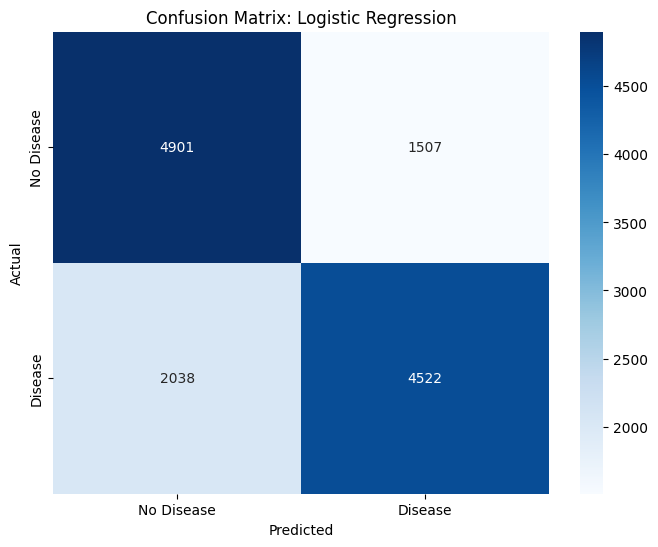

In [7]:
# Create and plot the confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Disease', 'Disease'], 
            yticklabels=['No Disease', 'Disease'])

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix: Logistic Regression')
plt.show()

### 8: Saving the Model and Scaler

NOTE: Since we scaled the data manually, we must save the SCALER too!
 , In the app, we will need to load both.

In [8]:
import pickle

# Extract the final optimized model
final_model = grid_search.best_estimator_

# Save both model and scaler to a single pickle file
with open('cardio_model_lr.pkl', 'wb') as f:
    pickle.dump((final_model, standardScaler), f)

print("Optimized Model and Scaler saved as 'cardio_model_lr.pkl' successfully!")

Optimized Model and Scaler saved as 'cardio_model_lr.pkl' successfully!


### **Task-3: Modeling & Evaluation Summary**

| Step | Technique / Tool | Logic & Threshold | Rationale |
| :--- | :--- | :--- | :--- |
| **Data Split** | `train_test_split` | 80% Train / 20% Test | Separates data to ensure the model is evaluated on unseen data to prevent overfitting. |
| **Feature Scaling** | `StandardScaler` | Mean = 0, Std = 1 | Normalizes the range of independent variables so features like `age` and `high_bp` contribute equally to the model. |
| **Model Selection** | `LogisticRegression` | Binary Classification | A robust statistical method used to predict the probability of a binary outcome (Cardio vs. No Cardio). |
| **Optimization** | `GridSearchCV` | 5-Fold Cross Validation | Automatically tests multiple combinations of hyperparameters (`C`, `penalty`, `solver`) to find the most accurate model version. |
| **Performance** | `accuracy_score` | Overall Percentage | Measures the proportion of total cases correctly identified by the model. |
| **Deep Evaluation** | `confusion_matrix` | True/False Positives/Negatives | Provides a detailed breakdown of correct and incorrect predictions for each class (Disease vs. No Disease). |
| **Model Persistence** | `pickle` | Serialized Output | Saves the finalized model and scaler into a `.pkl` file for use in real-time prediction applications without retraining. |